In [24]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import adam_v2
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

sns.set(style='white', context='notebook', palette='deep')

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [25]:
train_data = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
test_data = pd.read_csv("/kaggle/input/digit-recognizer/test.csv")

submission_data = pd.read_csv('/kaggle/input/digit-recognizer/sample_submission.csv')

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: label, dtype: int64

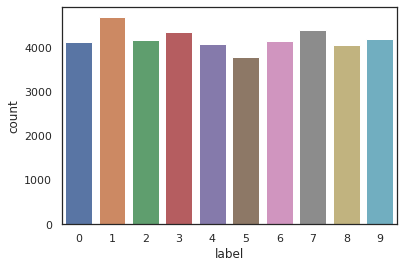

In [26]:
Y_train = train_data["label"].astype('int32')

X_train = train_data.drop(labels = ["label"],axis = 1) 

### Learning 1 -> check the distribution of output to see if it is uniform
g = sns.countplot(Y_train)

Y_train.value_counts()

In [27]:
### Lesson 2 -> Check for NULL values in train data. This is an indication that the image
### is corrupted
train_data.isnull().sum().sum()

0

In [28]:
test_data.isnull().sum().sum()

0

In [29]:
X_train = X_train.values.astype('float32') / 255.0
test_data = test_data.values.astype('float32') / 255.0

In [30]:
X_train = X_train.reshape(-1,28,28,1)
test_data = test_data.reshape(-1,28,28,1)

In [31]:
# Split the train and the validation set for the fitting
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size = 0.1, random_state=42)

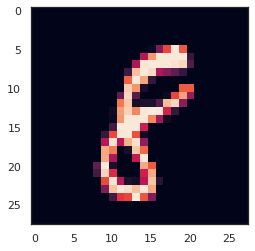

In [32]:
# Some examples
g = plt.imshow(X_train[0][:,:,0])

In [33]:
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same', 
                 activation ='relu', input_shape = (28,28,1)))
model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same', 
                 activation ='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))


model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same', 
                 activation ='relu'))
model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same', 
                 activation ='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))


model.add(Flatten())
model.add(Dense(256, activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation = "softmax"))

In [34]:
### Compile the model
model.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              optimizer=keras.optimizers.Adam(learning_rate=0.003),
              metrics=['accuracy'])

In [35]:
### Lesson 3 -> Callback functions in Keras. Can add multiple callbacks like stop training
### printing certain logs etc.
learning_rate_reduction = ReduceLROnPlateau(monitor='val_acc', 
                                            patience=3, 
                                            verbose=1, 
                                            factor=0.5, 
                                            min_lr=0.00001)

In [36]:
### Lesson 4 -> Data Augmentation. Be careful of what data augmentation features to use
### For ex: in this case we cannot flip an image horizontally or vertically because 9 can
### become 6 and vice versa

datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.1, # Randomly zoom image 
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=False,  # randomly flip images
        vertical_flip=False)  # randomly flip images


datagen.fit(X_train)

In [37]:
print(X_train.shape)

(37800, 28, 28, 1)


In [38]:
training_generator = datagen.flow(X_train,Y_train, batch_size=86)

In [39]:
print(training_generator)

In [48]:
### Lesson 5 -> fitting data on augmented images
### How many more images are created? How to find that out?
history = model.fit(datagen.flow(X_train,Y_train, batch_size=86),
                              epochs = 30, validation_data = (X_val,Y_val),
                              verbose = 2, callbacks=[learning_rate_reduction,keras.callbacks.EarlyStopping(monitor='val_loss', patience=4,min_delta=0.0001)])

Epoch 1/30
440/440 - 9s - loss: 0.0712 - accuracy: 0.9810 - val_loss: 0.0396 - val_accuracy: 0.9902
Epoch 2/30
440/440 - 10s - loss: 0.0695 - accuracy: 0.9811 - val_loss: 0.0463 - val_accuracy: 0.9890
Epoch 3/30
440/440 - 9s - loss: 0.0727 - accuracy: 0.9804 - val_loss: 0.0376 - val_accuracy: 0.9919
Epoch 4/30
440/440 - 9s - loss: 0.0760 - accuracy: 0.9790 - val_loss: 0.0358 - val_accuracy: 0.9914
Epoch 5/30
440/440 - 10s - loss: 0.0725 - accuracy: 0.9804 - val_loss: 0.0328 - val_accuracy: 0.9914
Epoch 6/30
440/440 - 9s - loss: 0.0714 - accuracy: 0.9807 - val_loss: 0.0425 - val_accuracy: 0.9905
Epoch 7/30
440/440 - 9s - loss: 0.0716 - accuracy: 0.9802 - val_loss: 0.0372 - val_accuracy: 0.9914
Epoch 8/30
440/440 - 9s - loss: 0.0765 - accuracy: 0.9787 - val_loss: 0.0356 - val_accuracy: 0.9912
Epoch 9/30
440/440 - 9s - loss: 0.0751 - accuracy: 0.9794 - val_loss: 0.0354 - val_accuracy: 0.9917


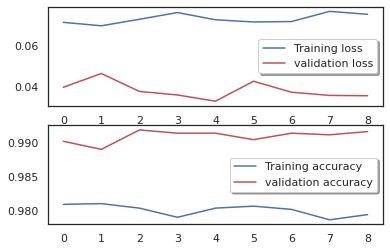

In [51]:
## Plotting the loss and accurarcy for training and validation data set
fig,ax = plt.subplots(2,1)

ax[0].plot(history.history['loss'],color='b',label="Training loss")
ax[0].plot(history.history['val_loss'],color='r',label="validation loss")
legend = ax[0].legend(loc='best', shadow=True)

ax[1].plot(history.history['accuracy'],color='b',label="Training accuracy")
ax[1].plot(history.history['val_accuracy'],color='r',label="validation accuracy")
legend = ax[1].legend(loc='best', shadow=True)

In [41]:
Y_pred_val = model.predict(X_val)
print(Y_pred_val)

Y_pred_val_class = np.argmax(Y_pred_val,axis=1)

### Y_val -> true values for validation dataset

confusion_mtx = confusion_matrix(Y_val,Y_pred_val_class)

[[9.2428314e-19 3.4920443e-32 8.3533055e-16 ... 4.5364558e-30
  1.0000000e+00 4.4828177e-15]
 [1.6310119e-15 1.0000000e+00 1.5998757e-13 ... 1.5158940e-09
  1.5369276e-14 3.4075958e-12]
 [2.5684800e-21 4.8811459e-16 2.1753275e-16 ... 1.5591727e-10
  8.2113353e-13 1.0000000e+00]
 ...
 [4.9311909e-12 2.9842806e-08 9.1328866e-07 ... 9.9999416e-01
  1.2655998e-11 1.9890556e-06]
 [2.0906736e-18 1.6266432e-12 4.6202902e-13 ... 1.0000000e+00
  7.6951567e-17 2.4458744e-09]
 [1.5450767e-23 5.9214069e-26 8.4629599e-25 ... 1.8694351e-24
  2.9537017e-19 2.4079518e-15]]


In [42]:
print(confusion_mtx)

[[408   0   0   0   0   0   0   0   0   0]
 [  0 469   0   0   0   0   1   1   0   0]
 [  0   0 416   2   0   0   0   1   1   0]
 [  0   0   0 505   0   0   0   1   0   0]
 [  0   0   0   0 393   0   0   0   1   3]
 [  0   0   0   2   0 331   1   0   2   3]
 [  0   0   0   0   1   1 399   0   1   0]
 [  0   1   0   0   1   0   0 435   1   0]
 [  1   1   0   0   0   0   0   0 401   0]
 [  2   0   0   0   0   0   0   1   1 412]]


In [43]:
### Lesson 6 -> Check what values in the validation set are misclassified
errors = (Y_pred_val_class - Y_val != 0)

Y_pred_misclassified = Y_pred_val_class[errors]

## Getting the probabilites of wrongly predicted numbers
Y_pred_probabilities = Y_pred_val[errors]
Y_pred_errors_prob = np.max(Y_pred_probabilities,axis=1)

Y_pred_true = Y_val[errors]
X_val_misclassified = X_val[errors]

true_prob_errors = np.diagonal(np.take(Y_pred_probabilities, Y_pred_true, axis=1))
delta_pred_true_errors = Y_pred_errors_prob - true_prob_errors

# Sorted list of the delta prob errors
sorted_dela_errors = np.argsort(delta_pred_true_errors)

# Top 6 errors 
most_important_errors = sorted_dela_errors[-6:]

In [44]:
print(Y_pred_misclassified)
print(Y_pred_true)

[0 8 4 9 5 0 3 0 7 6 8 9 3 7 7 9 8 6 1 9 1 3 8 8 9 3 8 8 4 9 7]
37896    9
27034    5
24210    7
39331    5
27977    6
40354    9
13611    5
19321    8
8194     9
10803    5
24307    6
26182    4
10644    2
32763    3
13477    1
6112     4
36978    7
24891    1
7725     7
36975    5
40238    8
34902    5
11942    4
29678    9
19607    4
5288     2
24971    2
13609    5
10941    6
26341    5
25795    2
Name: label, dtype: int32


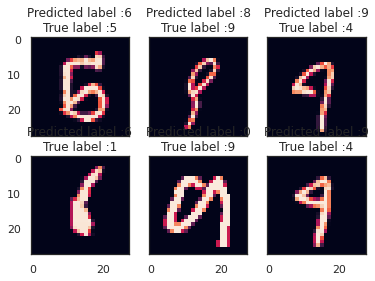

In [45]:
def display_errors(errors_index,img_errors,pred_errors, obs_errors):
    """ This function shows 6 images with their predicted and real labels"""
    n = 0
    nrows = 2
    ncols = 3
    fig, ax = plt.subplots(nrows,ncols,sharex=True,sharey=True)
    for row in range(nrows):
        for col in range(ncols):
            error = errors_index[n]
            ax[row,col].imshow((img_errors[error]).reshape((28,28)))
            ax[row,col].set_title("Predicted label :{}\nTrue label :{}".format(pred_errors[error],obs_errors[error]))
            n += 1

## Show top 6 errors
display_errors(most_important_errors, X_val_misclassified, Y_pred_misclassified, Y_pred_true.values)

In [47]:
prediction = model.predict(test_data)
Y_pred_classes = np.argmax(prediction, axis = 1)
final_conv2D = pd.DataFrame()

final_conv2D['ImageId'] =  submission_data['ImageId']
final_conv2D['label'] = Y_pred_classes

final_conv2D.to_csv('submit-Conv2D-predictions' + '.csv', index=False)